In [1]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from LLS import LLS

In [2]:
data = pd.read_csv("housing.csv")
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
data.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


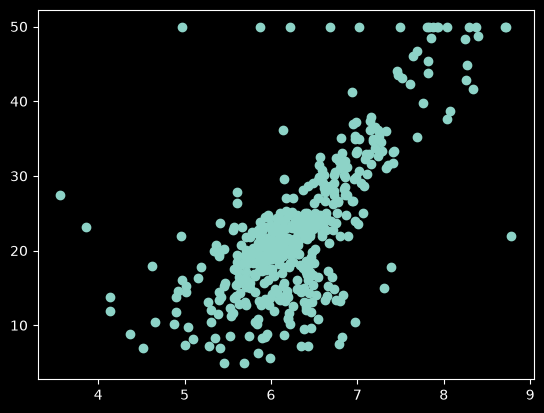

In [4]:
plt.scatter(data["RM"], data["MEDV"])
plt.show()

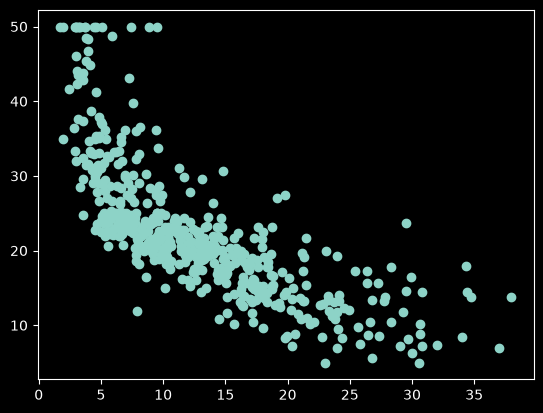

In [5]:
plt.scatter(data["LSTAT"], data["MEDV"])
plt.show()

# 2 Features
1) LSTAT : % lower status of the population
2)  RM : average number of rooms per dwelling
# 1 Target
1) MEDV : Median value of owner-occupied homes in $1000's


In [9]:
X = data[["RM","LSTAT"]]
Y = data["MEDV"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [10]:
lls = LLS()
lls.fit(X_train, Y_train)
w = lls.calculate_slope()

array([[ 4.92173014],
       [-0.67343132]])

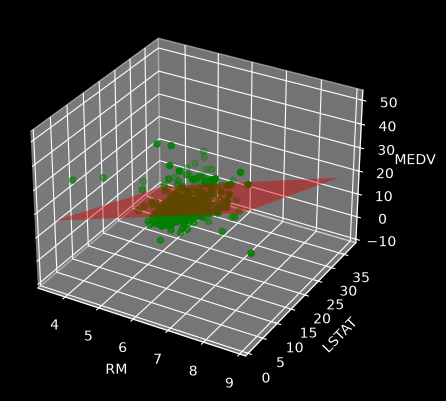

In [22]:
# X1 = lls.x_train[:,0]
# X2 = lls.x_train[:,1]
#
# x1, x2 = np.meshgrid(X1, X2)
# eq = w[0] * x1 + w[1] * x2
X1 = lls.x_train[:, 0]
X2 = lls.x_train[:, 1]

x1 = np.linspace(X1.min(), X1.max(), 50)
x2 = np.linspace(X2.min(), X2.max(), 50)

x1, x2 = np.meshgrid(x1, x2)

eq = w[0] * x1 + w[1] * x2


# fig = plt.figure()
#
# ax = fig.add_subplot(111,projection='3d')
# ax.scatter(X1 , X2 , lls.y_train,  color='green',alpha=0.5)
# ax.plot_surface(x1, x2, eq)
# ax.set_xlabel('RM')
# ax.set_ylabel('LSTAT')
# ax.set_zlabel('MEDV')
# plt.show()
fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X1,
    X2,
    lls.y_train.ravel(),
    color='green'
)

ax.plot_surface(x1, x2, eq, alpha=0.5,color='red')

ax.set_xlabel('RM')
ax.set_ylabel('LSTAT')
ax.set_zlabel('MEDV')

plt.show()